# P-RICE: XGBoost Forecasting Model for Philippine Rice Prices
**All 8 rice types · Monthly · 1–6 months ahead · XGBoost vs ARIMA vs Naive · SHAP**

How this notebook works (run top to bottom with **Run All**):
1. **Load data**: combines all 8 rice CSVs into one table and converts weekly → monthly.
2. **Features**: past prices, past price changes, predictors (oil, farmgate, inflation, stocks, rainfall), rice type (categorical), and target month. Only information available *at the time of forecasting* is used, so there is no data leakage.
3. **Target**: the model predicts the **price change** from the current month, then adds it back to the current price. This lets XGBoost follow prices outside the range it has seen.
4. **Split**: chronological 80-10-10 (train / validation / test).
5. **Tuning**: RandomizedSearchCV with time-ordered folds, then early stopping on the validation set.
6. **Walk-forward validation**: the model is retrained every month on all data known up to that month.
7. **Benchmarks**: ARIMA (order chosen by AIC) and Naive ("price stays the same").
8. **Metrics**: MAE, RMSE, MAPE. **Feature importance**: SHAP.

When the final data (e.g. OpenSTAT monthly) is ready, only the **Load data** cell needs to change.

In [1]:
# Install libraries (safe to re-run; does nothing if already installed)
%pip install -q xgboost scikit-learn pandas numpy matplotlib statsmodels openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from IPython.display import display

pd.set_option("display.width", 200)

## 1. Settings
Change these values to run different experiments.

In [3]:
# Rice data files: (Origin, Variety) -> file name
FILES = {
    ("Local", "Special"):           "Local Special Rice.csv",
    ("Local", "Premium"):           "Local Premium Rice.csv",
    ("Local", "Well-milled"):       "Local Well-milled Rice.csv",
    ("Local", "Regular-milled"):    "Local Regular-Milled Rice.csv",
    ("Imported", "Special"):        "Imported Special Rice.csv",
    ("Imported", "Premium"):        "Imported Premium Rice.csv",
    ("Imported", "Well-milled"):    "Imported Well-milled Rice.csv",
    ("Imported", "Regular-milled"): "Imported Regular-milled Rice.csv",
}

# Predictors (exogenous factors)
EXOG = ["Brent_Oil_USD", "Farmgate_LCU_tonne", "Inflation_Rate", "Stocks_MT", "USD_to_PHP", "Temp_C", "Rainfall_mm", "VoP_MT"]

FREQ = "MS"                    # "MS" = monthly. Set to None to keep the original weekly data.
HORIZONS = [1, 2, 3, 4, 5, 6]  # how many periods (months) ahead to forecast
PRICE_LAGS = 3                 # how many past months of prices the model sees
SPLIT = (0.80, 0.10, 0.10)     # train / validation / test (chronological)
N_ITER = 30                    # RandomizedSearchCV: number of random setting combinations to try
PLOT_HORIZON = 1               # horizon used for the actual-vs-predicted charts
SHAP_HORIZON = 1               # horizon used for the SHAP analysis
RANDOM_STATE = 42

# Hyperparameter search space (Table 3 of the paper)
PARAM_GRID = {
    "max_depth":        [2, 3, 4],
    "learning_rate":    [0.01, 0.03, 0.05],
    "subsample":        [0.6, 0.7, 0.8],
    "colsample_bytree": [0.6, 0.7, 0.8],
    "min_child_weight": [3, 5, 10],
    "reg_alpha":        [0.1, 1.0, 5.0],
    "reg_lambda":       [1.0, 5.0, 10.0],
    "gamma":            [0.1, 0.5, 1.0],
}

## 2. Load data
Reads each rice file, keeps only the price and the base predictors (the pre-made lag columns and `Price_Change` are rebuilt later in a leakage-free way), and converts weekly data to monthly averages.

**To use new data later:** this cell just needs to produce a table with the columns `Date, Price, Origin, Variety, Series` plus the predictor columns in `EXOG`.

In [4]:
def load_series(path, origin, variety):
    d = pd.read_csv(path)
    price_col = [c for c in d.columns if "_PHP_kg_" in c and "_lag" not in c][0]
    d = d[["Date", price_col] + EXOG].rename(columns={price_col: "Price"})
    d["Date"] = pd.to_datetime(d["Date"])
    if FREQ:
        d = d.set_index("Date").resample(FREQ).mean().reset_index()   # weekly -> monthly average
    d["Origin"], d["Variety"] = origin, variety
    d["Series"] = f"{origin} {variety}"
    return d

data = pd.concat([load_series(f, o, v) for (o, v), f in FILES.items()], ignore_index=True)
SERIES = list(data["Series"].unique())

display(data)
print(data.groupby("Series")["Date"].agg(["min", "max", "count"]))

,Date,Price,Brent_Oil_USD,Farmgate_LCU_tonne,Inflation_Rate,Stocks_MT,USD_to_PHP,Temp_C,Rainfall_mm,VoP_MT,Origin,Variety,Series
0,2023-08-01,57.8000,82.50,17740.0,8.7,651930.00,56.1599,26.6500,6.2200,292142.87,Local,Special,Local Special
1,2023-09-01,58.3660,82.59,18190.0,8.6,541210.00,56.7869,27.2320,8.6220,292142.87,Local,Special,Local Special
2,2023-10-01,58.1450,78.43,18570.0,7.6,494252.94,56.7889,26.5675,8.6175,556578.48,Local,Special,Local Special
3,2023-11-01,59.4375,84.64,18790.0,6.6,728730.70,55.8122,25.8125,10.0300,556578.48,Local,Special,Local Special
4,2023-12-01,60.9660,75.47,19060.0,6.1,787970.99,55.5877,25.3680,11.2160,556578.48,Local,Special,Local Special
...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,2026-02-01,40.9075,71.04,17360.0,0.9,1343908.45,58.2803,23.8375,4.7225,338099.00,Imported,Regular-milled,Imported Regular-milled
276,2026-03-01,42.4600,67.87,17060.0,1.5,1030751.52,59.4069,24.2475,1.0600,338099.00,Imported,Regular-milled,Imported Regular-milled
277,2026-04-01,43.0550,67.99,15600.0,1.7,815346.38,60.2913,27.3225,0.1025,356076.21,Imported,Regular-milled,Imported Regular-milled
278,2026-05-01,43.0600,64.54,15890.0,1.7,954908.93,61.4410,29.4520,2.1920,356076.21,Imported,Regular-milled,Imported Regular-milled


                               min        max  count
Series                                              
Imported Premium        2023-08-01 2026-06-01     35
Imported Regular-milled 2023-08-01 2026-06-01     35
Imported Special        2023-08-01 2026-06-01     35
Imported Well-milled    2023-08-01 2026-06-01     35
Local Premium           2023-08-01 2026-06-01     35
Local Regular-milled    2023-08-01 2026-06-01     35
Local Special           2023-08-01 2026-06-01     35
Local Well-milled       2023-08-01 2026-06-01     35


## 3. Chronological 80-10-10 split
The split is based on **dates**, so every rice type and every horizon is tested on the same months.

In [5]:
all_dates = np.sort(data["Date"].unique())
n_dates = len(all_dates)
TRAIN_END = all_dates[int(n_dates * SPLIT[0]) - 1]
VAL_END   = all_dates[int(n_dates * (SPLIT[0] + SPLIT[1])) - 1]

fmt = lambda d: pd.Timestamp(d).strftime("%b %Y")
print(f"Total periods : {n_dates}")
print(f"Train         : {fmt(all_dates[0])} - {fmt(TRAIN_END)}")
print(f"Validation    : after {fmt(TRAIN_END)} - {fmt(VAL_END)}")
print(f"Test          : after {fmt(VAL_END)} - {fmt(all_dates[-1])}")

Total periods : 35
Train         : Aug 2023 - Nov 2025
Validation    : after Nov 2025 - Feb 2026
Test          : after Feb 2026 - Jun 2026


## 4. Feature engineering (leakage-free)
For a forecast made at month **t** for month **t + h**:
- `Price_lag0..3`: price at t, t-1, t-2, t-3
- `Change_lag0..2`: monthly price changes up to month t
- predictors at t and t-1 (`_lag0`, `_lag1`)
- `Origin_*`, `Variety_*`: rice type as **categorical** (0/1) columns
- `Target_Month`: calendar month being forecast (seasonality)

**Target** `y` = price(t + h) − price(t). Predicted price = price(t) + predicted change.

In [6]:
META = ["Series", "Origin_Date", "Target_Date", "Base_Price", "Actual", "y", "Set"]

def make_features(df, h):
    parts = []
    for s, g in df.groupby("Series"):
        g = g.sort_values("Date").reset_index(drop=True)
        f = pd.DataFrame({"Series": s, "Origin": g["Origin"], "Variety": g["Variety"],
                          "Origin_Date": g["Date"], "Target_Date": g["Date"].shift(-h)})
        for k in range(PRICE_LAGS + 1):
            f[f"Price_lag{k}"] = g["Price"].shift(k)
        for k in range(PRICE_LAGS):
            f[f"Change_lag{k}"] = g["Price"].shift(k) - g["Price"].shift(k + 1)
        for c in EXOG:
            f[f"{c}_lag0"] = g[c]
            f[f"{c}_lag1"] = g[c].shift(1)
        f["Target_Month"] = f["Target_Date"].dt.month
        f["Base_Price"] = g["Price"]
        f["Actual"] = g["Price"].shift(-h)
        f["y"] = f["Actual"] - f["Base_Price"]
        parts.append(f)
    out = pd.concat(parts, ignore_index=True).dropna()
    out = pd.get_dummies(out, columns=["Origin", "Variety"], dtype=int)   # categorical -> 0/1 columns
    out["Set"] = np.where(out["Target_Date"] <= TRAIN_END, "Train",
                 np.where(out["Target_Date"] <= VAL_END, "Validation", "Test"))
    return out.sort_values(["Target_Date", "Series"]).reset_index(drop=True)

example = make_features(data, 1)
FEATURES = [c for c in example.columns if c not in META]
print(f"{len(FEATURES)} features:", FEATURES)
print(example["Set"].value_counts())

30 features: ['Price_lag0', 'Price_lag1', 'Price_lag2', 'Price_lag3', 'Change_lag0', 'Change_lag1', 'Change_lag2', 'Brent_Oil_USD_lag0', 'Brent_Oil_USD_lag1', 'Farmgate_LCU_tonne_lag0', 'Farmgate_LCU_tonne_lag1', 'Inflation_Rate_lag0', 'Inflation_Rate_lag1', 'Stocks_MT_lag0', 'Stocks_MT_lag1', 'USD_to_PHP_lag0', 'USD_to_PHP_lag1', 'Temp_C_lag0', 'Temp_C_lag1', 'Rainfall_mm_lag0', 'Rainfall_mm_lag1', 'VoP_MT_lag0', 'VoP_MT_lag1', 'Target_Month', 'Origin_Imported', 'Origin_Local', 'Variety_Premium', 'Variety_Regular-milled', 'Variety_Special', 'Variety_Well-milled']
Set
Train         192
Test           32
Validation     24
Name: count, dtype: int64


## 5. Model functions
- **Tuning**: RandomizedSearchCV over the Table 3 grid, using time-ordered folds (never shuffled), scored by MAE. Then early stopping on the validation set picks the number of trees (max 1000).
- **Walk-forward**: for each forecast month, retrain on all rows whose actual value was already known at that time, then predict.
- **ARIMA**: order (p, d, q) chosen by lowest AIC on the training period only, then re-fitted at every walk-forward step.
- **Naive**: forecast = latest known price.

In [7]:
def time_folds(frame, n_splits=3):
    # Cross-validation folds split by date (earlier dates train, later dates validate)
    ud = np.sort(frame["Target_Date"].unique())
    folds = []
    for tr, te in TimeSeriesSplit(n_splits=n_splits).split(ud):
        folds.append((np.where(frame["Target_Date"].isin(ud[tr]))[0],
                      np.where(frame["Target_Date"].isin(ud[te]))[0]))
    return folds

def tune_xgb(feat):
    train = feat[feat["Set"] == "Train"].reset_index(drop=True)
    val = feat[feat["Set"] == "Validation"]
    search = RandomizedSearchCV(
        xgb.XGBRegressor(objective="reg:squarederror", n_estimators=300, random_state=RANDOM_STATE),
        PARAM_GRID, n_iter=N_ITER, cv=time_folds(train), scoring="neg_mean_absolute_error",
        random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(train[FEATURES], train["y"])
    params = search.best_params_
    # Early stopping on the validation set (n_estimators up to 1000)
    es = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=1000, early_stopping_rounds=50,
                          eval_metric="mae", random_state=RANDOM_STATE, **params)
    es.fit(train[FEATURES], train["y"], eval_set=[(val[FEATURES], val["y"])], verbose=False)
    return params, es.best_iteration + 1

def walk_forward_xgb(feat, params, n_rounds):
    eval_rows = feat[feat["Set"] != "Train"]
    pred = pd.Series(index=eval_rows.index, dtype=float)
    model = None
    for origin in np.sort(eval_rows["Origin_Date"].unique()):
        known = feat[feat["Target_Date"] <= origin]            # only data known at forecast time
        model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=n_rounds,
                                 random_state=RANDOM_STATE, **params)
        model.fit(known[FEATURES], known["y"])
        idx = eval_rows.index[eval_rows["Origin_Date"] == origin]
        pred.loc[idx] = model.predict(feat.loc[idx, FEATURES])
    return feat.loc[eval_rows.index, "Base_Price"] + pred, model   # price = current price + predicted change

def choose_arima_order(y_train):
    best, best_aic = (1, 1, 0), np.inf
    for p in range(3):
        for d in range(2):
            for q in range(3):
                try:
                    aic = ARIMA(y_train, order=(p, d, q)).fit().aic
                    if aic < best_aic:
                        best, best_aic = (p, d, q), aic
                except Exception:
                    pass
    return best

def mape(a, p):
    a, p = np.asarray(a), np.asarray(p)
    return np.mean(np.abs((a - p) / a)) * 100

def scores(a, p):
    return {"MAE": mean_absolute_error(a, p),
            "RMSE": np.sqrt(mean_squared_error(a, p)),
            "MAPE (%)": mape(a, p)}

## 6. ARIMA orders (chosen on training data only)

In [8]:
arima_orders = {}
for s in SERIES:
    y_tr = data[(data["Series"] == s) & (data["Date"] <= TRAIN_END)].sort_values("Date")["Price"].values
    arima_orders[s] = choose_arima_order(y_tr)
pd.Series(arima_orders, name="ARIMA (p, d, q)").to_frame()

C:\Users\Demi\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Demi\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Demi\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Demi\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Demi\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Lik

,"ARIMA (p, d, q)"
Local Special,"(0, 1, 0)"
Local Premium,"(1, 1, 1)"
Local Well-milled,"(0, 1, 2)"
Local Regular-milled,"(2, 1, 1)"
Imported Special,"(0, 1, 1)"
Imported Premium,"(1, 1, 0)"
Imported Well-milled,"(0, 1, 1)"
Imported Regular-milled,"(1, 1, 0)"


## 6b. How many lags should the model use?
Two checks, both using **training/validation data only** (the test set stays unseen):

**Method 1: PACF (Partial Autocorrelation Function).** For each lag k, it measures how much the price k months ago still tells us about today's price, *after* removing the effect of the months in between. Bars outside the blue band are statistically significant. The last significant lag suggests how far back the model should look.

**Method 2: Lag search (experiment).** Try `PRICE_LAGS` = 1 to 6, run walk-forward on the **validation set**, and pick the number with the lowest average MAE. This matches Chapter 3: "lags will be dynamically optimized to identify the optimal lookback period that minimizes forecast error."

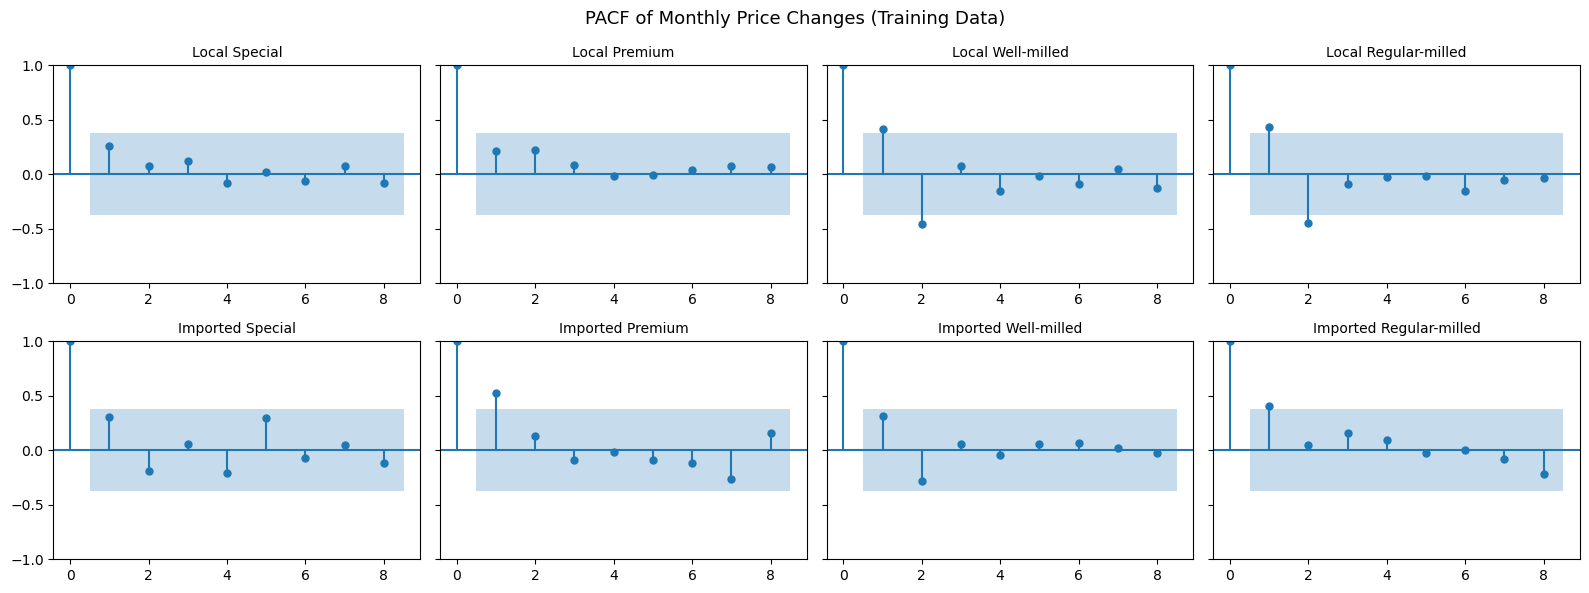

In [9]:
from statsmodels.graphics.tsaplots import plot_pacf

# Method 1: PACF of monthly price changes (differenced, so the series is stationary) on training data only
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey=True)
for ax, s in zip(axes.flat, SERIES):
    y_tr = data[(data["Series"] == s) & (data["Date"] <= TRAIN_END)].sort_values("Date")["Price"]
    plot_pacf(y_tr.diff().dropna(), lags=min(8, len(y_tr) // 2 - 2), ax=ax, method="ywm")
    ax.set_title(s, fontsize=10)
fig.suptitle("PACF of Monthly Price Changes (Training Data)", fontsize=13)
plt.tight_layout(); plt.show()

,h=1,h=2,h=3,h=4,h=5,h=6,Average MAE
PRICE_LAGS,,,,,,,
1,0.6277,1.1776,1.9113,2.7392,4.8917,5.7769,2.8541
2,0.6126,1.3973,1.7300,2.7411,5.0858,5.6003,2.8612
3,0.7321,1.1061,1.7857,2.9666,5.0010,5.4838,2.8459
4,0.7946,1.6039,2.9620,3.7408,5.1502,5.1756,3.2378
5,0.7403,1.9289,3.1765,4.1250,5.3127,6.0270,3.5517
6,0.7639,2.0699,3.5309,4.5752,5.5214,6.3752,3.8061


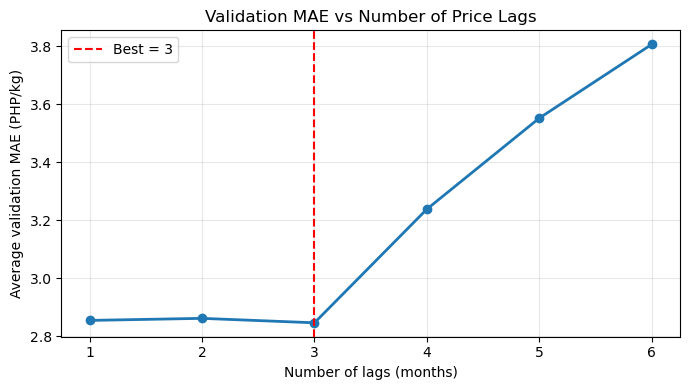

Selected PRICE_LAGS = 3  (30 features)


In [10]:
# Method 2: Lag search on the validation set (average over all horizons)
BASE_PARAMS = dict(max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                   min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0, gamma=0.1)

lag_results = []
for L in range(1, 7):
    PRICE_LAGS = L
    maes = []
    for h in HORIZONS:
        f = make_features(data, h)
        FEATURES = [c for c in f.columns if c not in META]
        val = f[f["Set"] == "Validation"]
        pred = pd.Series(index=val.index, dtype=float)
        for origin in np.sort(val["Origin_Date"].unique()):
            known = f[f["Target_Date"] <= origin]
            m = xgb.XGBRegressor(n_estimators=200, random_state=RANDOM_STATE, **BASE_PARAMS)
            m.fit(known[FEATURES], known["y"])
            idx = val.index[val["Origin_Date"] == origin]
            pred.loc[idx] = m.predict(f.loc[idx, FEATURES])
        maes.append(mean_absolute_error(val["Actual"], val["Base_Price"] + pred))
    lag_results.append({"PRICE_LAGS": L, **{f"h={h}": v for h, v in zip(HORIZONS, maes)},
                        "Average MAE": np.mean(maes)})

lag_table = pd.DataFrame(lag_results).set_index("PRICE_LAGS")
best_lag = int(lag_table["Average MAE"].idxmin())
display(lag_table.round(4))

plt.figure(figsize=(7, 4))
plt.plot(lag_table.index, lag_table["Average MAE"], "o-", linewidth=2)
plt.axvline(best_lag, color="red", linestyle="--", label=f"Best = {best_lag}")
plt.title("Validation MAE vs Number of Price Lags"); plt.xlabel("Number of lags (months)")
plt.ylabel("Average validation MAE (PHP/kg)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Use the best number of lags for the rest of the notebook
PRICE_LAGS = best_lag
FEATURES = [c for c in make_features(data, 1).columns if c not in META]
print(f"Selected PRICE_LAGS = {PRICE_LAGS}  ({len(FEATURES)} features)")

## 7. Run everything: tuning + walk-forward for each horizon
This takes a few minutes.

In [11]:
warnings.filterwarnings("ignore")   # hide ARIMA fitting warnings
results, models, feats, tuned = [], {}, {}, {}
arima_cache = {}   # (series, origin) -> forecasts for 1..max(HORIZONS)

for h in HORIZONS:
    feat = make_features(data, h)
    params, n_rounds = tune_xgb(feat)
    xgb_pred, last_model = walk_forward_xgb(feat, params, n_rounds)
    models[h], feats[h], tuned[h] = last_model, feat, {**params, "n_estimators": n_rounds}

    ev = feat[feat["Set"] != "Train"].copy()
    ev["XGBoost"] = xgb_pred
    ev["Naive"] = ev["Base_Price"]

    arima_pred = []
    for _, r in ev.iterrows():
        key = (r["Series"], r["Origin_Date"])
        if key not in arima_cache:
            hist = data[(data["Series"] == r["Series"]) & (data["Date"] <= r["Origin_Date"])]
            hist = hist.sort_values("Date")["Price"].values
            arima_cache[key] = ARIMA(hist, order=arima_orders[r["Series"]]).fit().forecast(max(HORIZONS))
        arima_pred.append(arima_cache[key][h - 1])
    ev["ARIMA"] = arima_pred
    ev["Horizon"] = h
    results.append(ev[["Horizon", "Series", "Origin_Date", "Target_Date", "Set",
                       "Actual", "XGBoost", "ARIMA", "Naive"]])
    print(f"h={h}: done | best settings: {tuned[h]}")

preds = pd.concat(results, ignore_index=True)
MODELS = ["XGBoost", "ARIMA", "Naive"]

h=1: done | best settings: {'subsample': 0.6, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.7, 'n_estimators': 582}
h=2: done | best settings: {'subsample': 0.6, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8, 'n_estimators': 457}
h=3: done | best settings: {'subsample': 0.6, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8, 'n_estimators': 1000}
h=4: done | best settings: {'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 5.0, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8, 'n_estimators': 245}
h=5: done | best settings: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytr

## 8. Results on the test set (all rice types combined)
Lower is better for all three metrics.

In [12]:
rows = []
for (h, st), g in preds.groupby(["Horizon", "Set"]):
    for m in MODELS:
        rows.append({"Horizon": h, "Set": st, "Model": m, **scores(g["Actual"], g[m])})
summary = pd.DataFrame(rows)
test_summary = summary[summary["Set"] == "Test"].drop(columns="Set")

for metric in ["MAE", "RMSE", "MAPE (%)"]:
    print(f"\n=== {metric} (Test set) ===")
    print(test_summary.pivot(index="Horizon", columns="Model", values=metric)[MODELS].round(4))


=== MAE (Test set) ===
Model    XGBoost   ARIMA   Naive
Horizon                         
1         0.9950  1.1166  1.1034
2         1.8729  2.2657  2.0842
3         2.4863  2.9725  2.9465
4         3.7231  3.7689  3.9114
5         5.0512  4.2395  4.5216
6         6.5940  4.7535  4.9823

=== RMSE (Test set) ===
Model    XGBoost   ARIMA   Naive
Horizon                         
1         1.4511  1.4593  1.5798
2         2.6494  3.0284  2.7839
3         3.2603  3.8962  3.6211
4         4.2175  4.6772  4.4321
5         5.6674  4.7262  5.1347
6         7.2725  5.4011  5.6601

=== MAPE (%) (Test set) ===
Model    XGBoost   ARIMA   Naive
Horizon                         
1         1.9509  2.1892  2.1530
2         3.5888  4.4602  4.0712
3         4.7912  5.8034  5.8014
4         7.2763  7.4630  7.6896
5         9.9290  8.3821  8.8811
6        12.9363  9.3427  9.7559


### How far ahead should P-RICE forecast?
For each horizon, check whether XGBoost has a lower MAE than both benchmarks. The recommended horizon is the **furthest** one where XGBoost still wins.

Model,XGBoost,ARIMA,Naive,Beats ARIMA,Beats Naive,Improvement vs ARIMA (%),Improvement vs Naive (%)
Horizon,,,,,,,
1,0.995,1.117,1.103,True,True,10.889,9.822
2,1.873,2.266,2.084,True,True,17.334,10.135
3,2.486,2.973,2.946,True,True,16.356,15.617
4,3.723,3.769,3.911,True,True,1.214,4.813
5,5.051,4.239,4.522,False,False,-19.147,-11.714
6,6.594,4.754,4.982,False,False,-38.718,-32.348


XGBoost beats both benchmarks at horizon(s): [1, 2, 3, 4]. Recommended horizon: up to 4 month(s) ahead.


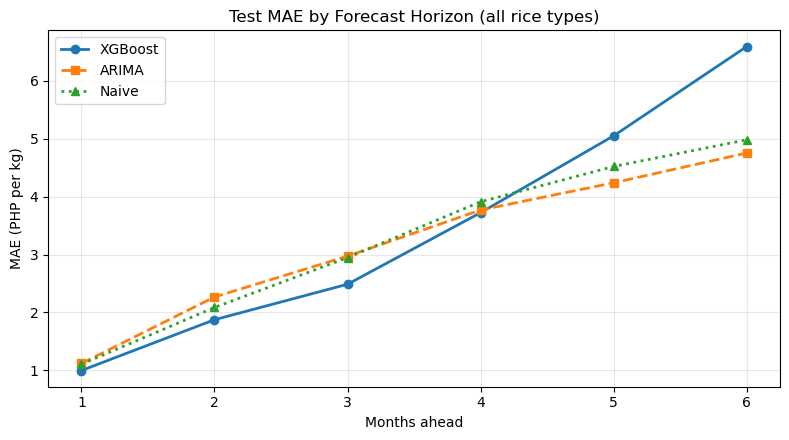

In [13]:
mae = test_summary.pivot(index="Horizon", columns="Model", values="MAE")[MODELS]
mae["Beats ARIMA"] = mae["XGBoost"] < mae["ARIMA"]
mae["Beats Naive"] = mae["XGBoost"] < mae["Naive"]
mae["Improvement vs ARIMA (%)"] = (1 - mae["XGBoost"] / mae["ARIMA"]) * 100
mae["Improvement vs Naive (%)"] = (1 - mae["XGBoost"] / mae["Naive"]) * 100
display(mae.round(3))

wins = mae.index[mae["Beats ARIMA"] & mae["Beats Naive"]].tolist()
if wins:
    print(f"XGBoost beats both benchmarks at horizon(s): {wins}. Recommended horizon: up to {max(wins)} month(s) ahead.")
else:
    print("XGBoost does not beat both benchmarks at any horizon on this test set.")

fig, ax = plt.subplots(figsize=(8, 4.5))
for m, style in zip(MODELS, ["o-", "s--", "^:"]):
    ax.plot(mae.index, mae[m], style, label=m, linewidth=2)
ax.set_title("Test MAE by Forecast Horizon (all rice types)")
ax.set_xlabel("Months ahead"); ax.set_ylabel("MAE (PHP per kg)")
ax.set_xticks(HORIZONS); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 9. Results per rice type (test set)

In [14]:
rows = []
for (h, s), g in preds[preds["Set"] == "Test"].groupby(["Horizon", "Series"]):
    for m in MODELS:
        rows.append({"Horizon": h, "Series": s, "Model": m, **scores(g["Actual"], g[m])})
by_series = pd.DataFrame(rows)

print(f"MAE per rice type at {PLOT_HORIZON} month(s) ahead (Test set):")
by_series[by_series["Horizon"] == PLOT_HORIZON].pivot(index="Series", columns="Model", values="MAE")[MODELS].round(3)

MAE per rice type at 1 month(s) ahead (Test set):


Model,XGBoost,ARIMA,Naive
Series,,,
Imported Premium,2.566,2.339,2.935
Imported Regular-milled,0.757,0.642,0.817
Imported Special,0.663,0.832,0.511
Imported Well-milled,0.806,0.616,0.346
Local Premium,0.960,1.180,1.238
Local Regular-milled,0.917,1.751,1.055
Local Special,0.362,0.604,0.604
Local Well-milled,0.929,0.969,1.320


## 10. Actual vs predicted (per rice type)
Line = actual price. Markers = forecasts during validation and test. Shaded area = test period.

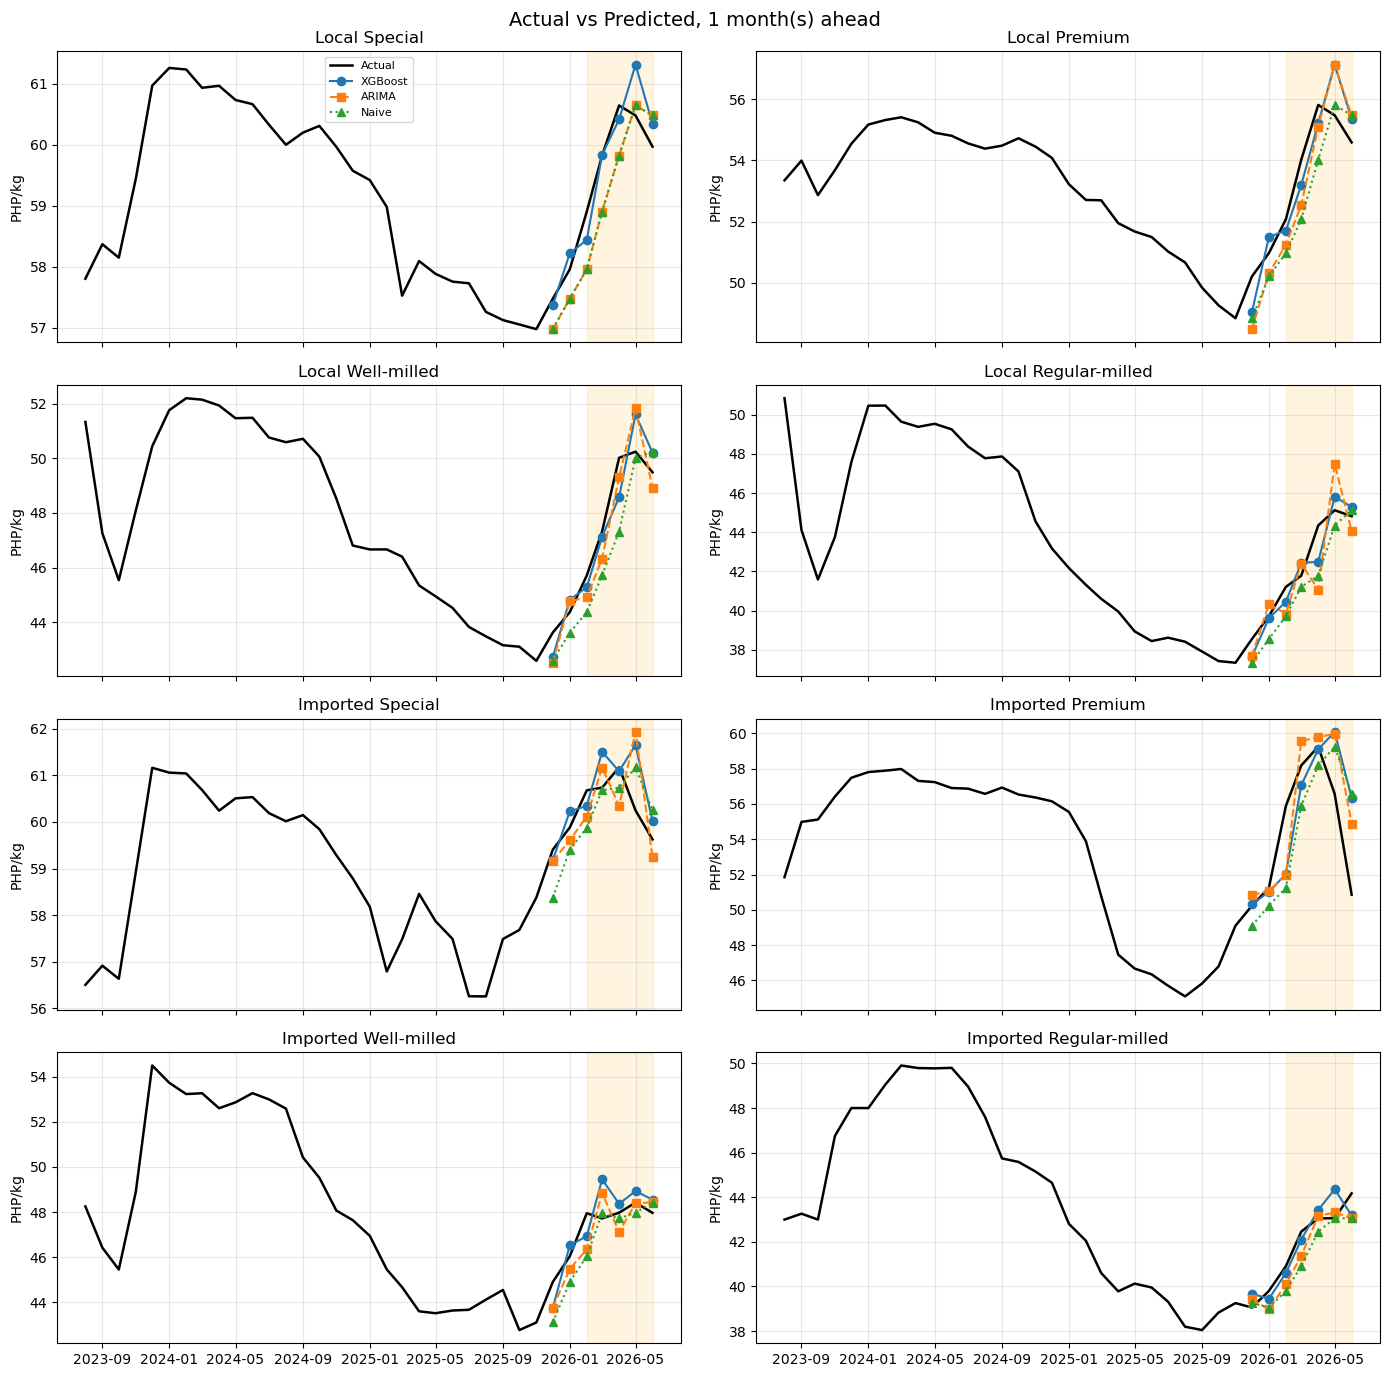

In [15]:
p = preds[preds["Horizon"] == PLOT_HORIZON]
fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
for ax, s in zip(axes.flat, SERIES):
    hist = data[data["Series"] == s].sort_values("Date")
    g = p[p["Series"] == s].sort_values("Target_Date")
    ax.plot(hist["Date"], hist["Price"], color="black", linewidth=1.8, label="Actual")
    ax.plot(g["Target_Date"], g["XGBoost"], "o-", label="XGBoost")
    ax.plot(g["Target_Date"], g["ARIMA"], "s--", label="ARIMA")
    ax.plot(g["Target_Date"], g["Naive"], "^:", label="Naive")
    ax.axvspan(pd.Timestamp(VAL_END), hist["Date"].max(), color="orange", alpha=0.12)
    ax.set_title(s); ax.set_ylabel("PHP/kg"); ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"Actual vs Predicted, {PLOT_HORIZON} month(s) ahead", fontsize=14)
plt.tight_layout(); plt.show()

## 11. SHAP feature importance
SHAP values are computed with XGBoost's built-in TreeSHAP (`pred_contribs=True`), which gives the exact SHAP values for tree models without needing the separate `shap` library.
- **Bar chart**: average absolute SHAP value = how much each feature moves the forecast on average.
- **Factor chart**: SHAP grouped by factor (e.g. all Brent oil columns together) = importance of each factor.
- **Dot chart**: each dot is one forecast. Right = pushed the price change up, left = pushed it down. Color = feature value (red high, blue low).

Computed on the held-out **test** data.

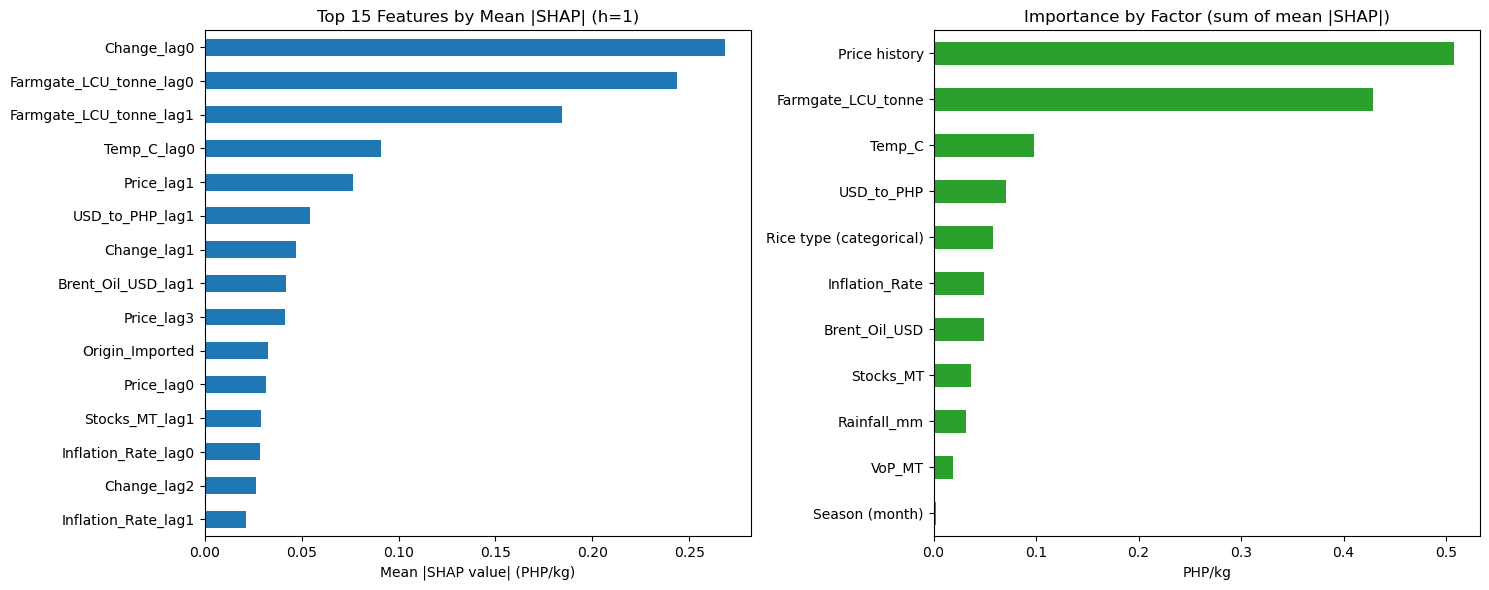

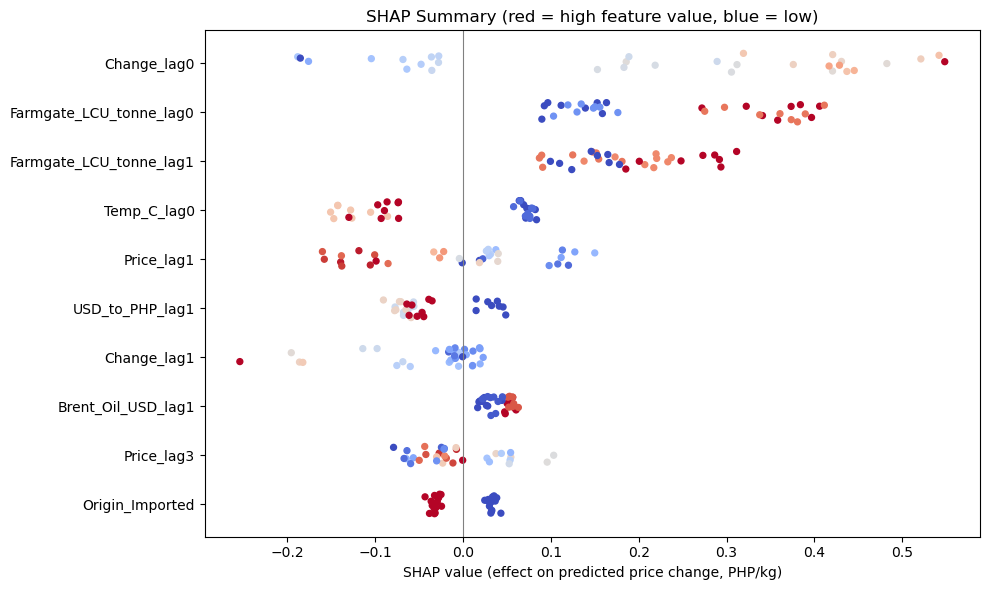

,Mean |SHAP| (PHP/kg)
Price history,0.5076
Farmgate_LCU_tonne,0.4284
Temp_C,0.0975
USD_to_PHP,0.0706
Rice type (categorical),0.0575
Inflation_Rate,0.0495
Brent_Oil_USD,0.0487
Stocks_MT,0.0366
Rainfall_mm,0.0317
VoP_MT,0.0189


In [16]:
feat = feats[SHAP_HORIZON]
X_test = feat.loc[feat["Set"] == "Test", FEATURES]
contrib = models[SHAP_HORIZON].get_booster().predict(xgb.DMatrix(X_test), pred_contribs=True)[:, :-1]
shap_df = pd.DataFrame(contrib, columns=FEATURES, index=X_test.index)

importance = shap_df.abs().mean().sort_values(ascending=False)

def factor_of(col):
    if col.startswith(("Price_lag", "Change_lag")): return "Price history"
    if col.startswith(("Origin_", "Variety_")):     return "Rice type (categorical)"
    if col == "Target_Month":                        return "Season (month)"
    for c in EXOG:
        if col.startswith(c): return c
    return col

factor_importance = importance.groupby(importance.index.map(factor_of)).sum().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
importance.head(15)[::-1].plot.barh(ax=ax[0], color="tab:blue")
ax[0].set_title(f"Top 15 Features by Mean |SHAP| (h={SHAP_HORIZON})"); ax[0].set_xlabel("Mean |SHAP value| (PHP/kg)")
factor_importance[::-1].plot.barh(ax=ax[1], color="tab:green")
ax[1].set_title("Importance by Factor (sum of mean |SHAP|)"); ax[1].set_xlabel("PHP/kg")
plt.tight_layout(); plt.show()

# Dot (beeswarm-style) summary plot for the top 10 features
top = importance.head(10).index[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
rng = np.random.default_rng(0)
for i, c in enumerate(top):
    v = X_test[c].astype(float)
    color = (v - v.min()) / (v.max() - v.min()) if v.max() > v.min() else v * 0 + 0.5
    ax.scatter(shap_df[c], i + rng.uniform(-0.2, 0.2, len(v)), c=color, cmap="coolwarm", s=18)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel("SHAP value (effect on predicted price change, PHP/kg)")
ax.set_title("SHAP Summary (red = high feature value, blue = low)")
plt.tight_layout(); plt.show()

factor_importance.round(4).to_frame("Mean |SHAP| (PHP/kg)")

## 12. Save results to Excel
Creates **P-RICE Results.xlsx** in this folder (does not overwrite `Evaluation Results.xlsx`).

In [17]:
with pd.ExcelWriter("P-RICE Results.xlsx") as w:
    test_summary.round(4).to_excel(w, sheet_name="Test Summary", index=False)
    summary.round(4).to_excel(w, sheet_name="Val+Test Summary", index=False)
    by_series.round(4).to_excel(w, sheet_name="Test by Rice Type", index=False)
    mae.round(4).to_excel(w, sheet_name="Horizon Decision")
    preds.round(4).to_excel(w, sheet_name="All Predictions", index=False)
    importance.round(4).to_frame("Mean |SHAP|").to_excel(w, sheet_name="SHAP Features")
    factor_importance.round(4).to_frame("Mean |SHAP|").to_excel(w, sheet_name="SHAP Factors")
    pd.DataFrame(tuned).T.to_excel(w, sheet_name="Best Settings")
    pd.Series(arima_orders).astype(str).to_frame("ARIMA order").to_excel(w, sheet_name="ARIMA Orders")
print("Saved: P-RICE Results.xlsx")

Saved: P-RICE Results.xlsx
